# Keyword Detection (TensorFlow)
This notebook contains the TensorFlow implementation of the Keyword Detection model with GPU support.

## Loading Requirements

In [1]:
import wave
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.model_selection import train_test_split

## 0. Check GPU Availability


In [2]:
def check_gpu_status():
    gpus = tf.config.list_physical_devices('GPU')
    print(f"CUDA Available: {len(gpus) > 0}")
    if gpus:
        print(f"Number of GPUs detected: {len(gpus)}\n")
        for i, gpu in enumerate(gpus):
            print(f"--- Available GPUs: {i} ---")
            print(f"Name: {gpu.name}")
    else:
        print("TensorFlow cannot detect a compatible GPU. It will default to CPU.")

check_gpu_status()

CUDA Available: False
TensorFlow cannot detect a compatible GPU. It will default to CPU.


## 1. Get Audio File Specifications


In [3]:
def check_wav_specs_tf(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return
    
    audio_bin = tf.io.read_file(file_path)

    audio, sample_rate = tf.audio.decode_wav(audio_bin, desired_channels=-1)
    
    # audio shape is [samples, channels]
    num_samples = tf.shape(audio)[0].numpy()
    num_channels = tf.shape(audio)[1].numpy()
    sample_rate = sample_rate.numpy()
    duration = num_samples / sample_rate

    print(f"Sample Rate: {sample_rate} Hz")
    print(f"Channels: {num_channels}")
    print(f"Frames (Samples): {num_samples}")
    print(f"Duration: {duration:.2f} seconds")
    
check_wav_specs_tf("../dataset/yes/1a673010_nohash_1.wav")

Sample Rate: 16000 Hz
Channels: 1
Frames (Samples): 16000
Duration: 1.00 seconds


## 2. Data Preparation

In [4]:
import json
import os
import random
from sklearn.model_selection import train_test_split

path_to_config = os.path.join('..', 'config.json')

try:
    with open(path_to_config, 'r') as f:
        config = json.load(f)
    print("Konfiguration erfolgreich geladen!")
except FileNotFoundError:
    print(f"Fehler: Datei nicht gefunden unter {os.path.abspath(path_to_config)}")
    raise

CLASSES = config["keywords"]
DATA_DIR = os.path.join('..', config["DATA_DIR"])
NUM_SAMPLES = config["num_samples"]
TARGET_SAMPLE_RATE = config["target_sample_rate"]
BATCH_SIZE = 32


def get_files_and_labels():
    file_paths = []
    labels = []
    class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASSES)}

    for cls_name in CLASSES:
        cls_dir = os.path.join(DATA_DIR, cls_name)
        if not os.path.exists(cls_dir):
            print(f"Warnung: Verzeichnis {cls_dir} nicht gefunden.")
            continue
        # Rekursive Suche, um verschachtelte Ordner unter 'other' zu finden
        for root, dirs, files in os.walk(cls_dir):
            for file in files:
                if file.endswith(".wav"):
                    file_paths.append(os.path.join(root, file))
                    labels.append(class_to_idx[cls_name])
    return file_paths, labels


file_paths, labels = get_files_and_labels()

if len(file_paths) > 0:
    # Balancing & Oversampling analog zu PyTorch
    other_idx = CLASSES.index("other")
    other_files = [f for f, l in zip(file_paths, labels) if l == other_idx]
    random.seed(42)
    downsampled_other = random.sample(other_files, min(len(other_files), 10000))
    
    keyword_files = {cls_name: [f for f, l in zip(file_paths, labels) if l == CLASSES.index(cls_name)]
                     for cls_name in CLASSES if cls_name != "other"}
    
    initial_paths = []
    initial_labels = []
    for cls_name, files in keyword_files.items():
        initial_paths.extend(files)
        initial_labels.extend([CLASSES.index(cls_name)] * len(files))
    initial_paths.extend(downsampled_other)
    initial_labels.extend([other_idx] * len(downsampled_other))
    
    # Stratified Split (70% Train, 15% Val, 15% Test)
    temp_paths, test_paths, temp_labels, test_labels = train_test_split(
        initial_paths, initial_labels, test_size=0.15, stratify=initial_labels, random_state=42
    )
    train_paths_raw, val_paths, train_labels_raw, val_labels = train_test_split(
        temp_paths, temp_labels, test_size=0.1765, stratify=temp_labels, random_state=42
    )
    
    # Oversampling Keyword-Klassen im Train-Set auf target_count = 8000
    target_count = 8000
    train_paths = []
    train_labels = []
    
    for cls_name in CLASSES:
        cls_idx = CLASSES.index(cls_name)
        cls_train_files = [f for f, l in zip(train_paths_raw, train_labels_raw) if l == cls_idx]
        
        if cls_name == "other":
            train_paths.extend(cls_train_files)
            train_labels.extend([cls_idx] * len(cls_train_files))
        else:
            oversampled = random.choices(cls_train_files, k=target_count)
            train_paths.extend(oversampled)
            train_labels.extend([cls_idx] * target_count)
            
    print(f"Erfolg: {len(file_paths)} Dateien gefunden.")
    print(f"Split-Übersicht:")
    print(f"  - Validation set size: {len(val_paths)} (stratified)")
    print(f"  - Test set size: {len(test_paths)} (stratified)")
    for cls_name in CLASSES:
        cls_idx = CLASSES.index(cls_name)
        print(f"    * {cls_name}: {sum(1 for l in train_labels if l == cls_idx)} train, {sum(1 for l in val_labels if l == cls_idx)} val, {sum(1 for l in test_labels if l == cls_idx)} test")
else:
    print(f"Keine Dateien gefunden! Gesuchter Pfad: {os.path.abspath(DATA_DIR)}")

Konfiguration erfolgreich geladen!


Erfolg: 64721 Dateien gefunden.


Split-Übersicht:
  - Validation set size: 2924 (stratified)
  - Test set size: 2923 (stratified)
    * yes: 8000 train, 357 val, 357 test
    * no: 8000 train, 356 val, 356 test
    * up: 8000 train, 356 val, 356 test
    * down: 8000 train, 354 val, 354 test
    * other: 6999 train, 1501 val, 1500 test


## 3. Dataset Pipeline (TensorFlow native audio layer)

In [5]:
## 3. Dataset Pipeline (TensorFlow native audio layer)

import tensorflow as tf

@tf.function
def process_path(file_path, label):
    # Read and decode wav
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Pad or cut to exactly NUM_SAMPLES
    audio_length = tf.shape(audio)[0]
    padding = tf.maximum(NUM_SAMPLES - audio_length, 0)
    audio = tf.pad(audio, [[0, padding]])
    audio = audio[:NUM_SAMPLES]

    return audio, label

@tf.function
def random_shift(audio, label):
    # Time Shifting: Random audio shift with zero-padding (matching PyTorch behavior)
    shift = tf.random.uniform([], -1600, 1600, dtype=tf.int32)
    audio_len = tf.shape(audio)[0]
    if shift > 0:
        audio = tf.pad(audio, [[shift, 0]])[:-shift]
    elif shift < 0:
        audio = tf.pad(audio, [[0, -shift]])[-shift:]
    return audio, label

def extract_mfcc(audio):
    # Pad audio matching PyTorch's default center padding for STFT (n_fft // 2)
    # n_fft is 400, so padding is 200 on both sides.
    padded_audio = tf.pad(audio, [[200, 200]])

    # 1. Compute STFT
    stfts = tf.signal.stft(
        padded_audio,
        frame_length=400,
        frame_step=200,
        fft_length=512
    )
    spectrograms = tf.abs(stfts)

    # 2. Warp to Mel scale
    num_spectrogram_bins = stfts.shape[-1]
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=64,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=TARGET_SAMPLE_RATE,
        lower_edge_hertz=80.0,
        upper_edge_hertz=7600.0
    )
    mel_spectrograms = tf.tensordot(spectrograms, linear_to_mel_weight_matrix, 1)

    # 3. Logarithm (with stabilization)
    log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)

    # 4. Extract MFCCs and keep the first 40 coefficients
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrograms)
    mfccs = mfccs[..., :40]  # Shape: (81, 40)

    # 5. Transpose to (40, 81) and expand dimensions to (40, 81, 1)
    mfccs = tf.transpose(mfccs, [1, 0])
    mfccs = tf.expand_dims(mfccs, axis=-1)

    return mfccs

@tf.function
def spec_augment(mfcc):
    # SpecAugment: Frequency and Time Masking in Pure TensorFlow graph
    mask_shape = tf.shape(mfcc)
    
    # Frequency masking (axis 0 of shape 40) - mask up to 6 bins
    f = tf.random.uniform([], 0, 6, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, 40 - f, dtype=tf.int32)
    indices_f = tf.range(mask_shape[0])
    f_mask = tf.cast((indices_f < f0) | (indices_f >= f0 + f), tf.float32)
    f_mask = tf.expand_dims(tf.expand_dims(f_mask, axis=-1), axis=-1)
    mfcc = mfcc * f_mask
    
    # Time masking (axis 1 of shape 81) - mask up to 12 bins
    t = tf.random.uniform([], 0, 12, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, 81 - t, dtype=tf.int32)
    indices_t = tf.range(mask_shape[1])
    t_mask = tf.cast((indices_t < t0) | (indices_t >= t0 + t), tf.float32)
    t_mask = tf.expand_dims(tf.expand_dims(t_mask, axis=0), axis=-1)
    mfcc = mfcc * t_mask
    
    return mfcc

def create_dataset(paths, labels, batch_size, shuffle=False, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))

    dataset = dataset.map(
        process_path,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if is_training:
        dataset = dataset.map(
            random_shift,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.map(
        lambda x, y: (extract_mfcc(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if is_training:
        dataset = dataset.map(
            lambda x, y: (spec_augment(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Erstelle die drei Datasets
train_ds = create_dataset(train_paths, train_labels, BATCH_SIZE, shuffle=True, is_training=True)
val_ds = create_dataset(val_paths, val_labels, BATCH_SIZE, shuffle=False, is_training=False)
test_ds = create_dataset(test_paths, test_labels, BATCH_SIZE, shuffle=False, is_training=False)

print("Alle drei TensorFlow Datasets (Train, Val, Test) wurden mit Data Augmentation erfolgreich erstellt.")

Alle drei TensorFlow Datasets (Train, Val, Test) wurden erfolgreich erstellt.


## 4. Model Architecture (with onboard MelSpectrogram on GPU)

In [6]:
# Mel spectrogram parameters mapping to 64 mels equivalent
frame_length = 1024
frame_step = 512
fft_length = 1024
num_mel_bins = 64
lower_edge_hertz = 80.0
upper_edge_hertz = 7600.0


def build_model(num_classes):

    mfcc_input = tf.keras.Input(
        shape=(40, 81, 1),
        name='mfcc_input'
    )

    x = mfcc_input

    # Block 1
    x = tf.keras.layers.Conv2D(16, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Resizing(4, 4)(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation='relu'
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        num_classes
    )(x)

    return tf.keras.Model(
        inputs=mfcc_input,
        outputs=outputs
    )

model = build_model(len(CLASSES))
model.summary()

print(model.input_shape)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 40, 81, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 81, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 81, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 81, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 40, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 20, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 20, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 10, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 10, 128)     │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 10, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 5, 10, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,789 (1.38 MB)

 Trainable params: 360,309 (1.37 MB)

 Non-trainable params: 480 (1.88 KB)

(None, 40, 81, 1)


## 5. Training Loop

In [7]:
LEARNING_RATE = 0.001
EPOCHS = 20

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

print(f"Starte Training für {EPOCHS} Epochen...")
print("TensorFlow nutzt automatisch die GPU, falls vorhanden.")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-5
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_scheduler]
)

Starte Training für 20 Epochen...
TensorFlow nutzt automatisch die GPU, falls vorhanden.
Epoch 1/20


   1/1219 ━━━━━━━━━━━━━━━━━━━━ 43:10 2s/step - accuracy: 0.1562 - loss: 2.5422

   3/1219 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.1736 - loss: 3.1262

   5/1219 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - accuracy: 0.1817 - loss: 3.3591

   7/1219 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.1841 - loss: 3.3782

...

1216/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9656 - loss: 0.0982

1217/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9656 - loss: 0.0982

1218/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9656 - loss: 0.0982

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9656 - loss: 0.0982

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 73s 60ms/step - accuracy: 0.9666 - loss: 0.0977 - val_accuracy: 0.9528 - val_loss: 0.2308


## 6. Visualization

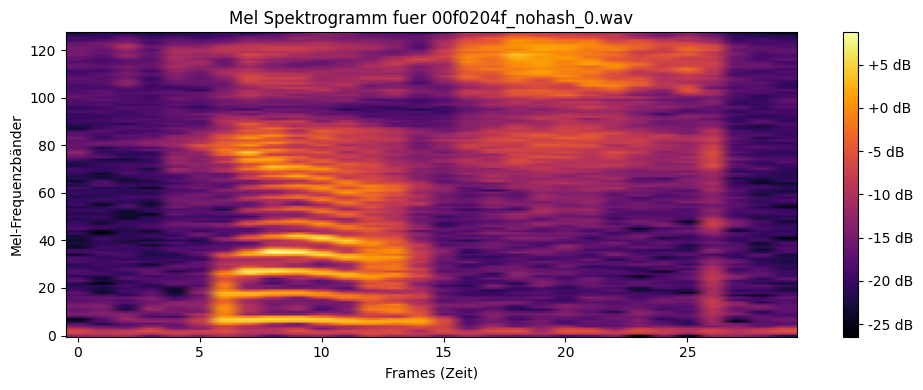

In [8]:
file_path = '../dataset/yes/00f0204f_nohash_0.wav'

if os.path.exists(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # STFT - Nutzt die Parameter von oben
    stfts = tf.signal.stft(audio, frame_length=frame_length, frame_step=frame_step, fft_length=fft_length)
    spectrograms = tf.abs(stfts)

    # Mel Spectrogram
    mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        128, spectrograms.shape[-1], TARGET_SAMPLE_RATE, lower_edge_hertz, upper_edge_hertz)
    mel_spectrograms = tf.tensordot(spectrograms, mel_weight_matrix, 1)

    # Amplitude to DB (log)
    log_mel_spectrogram = 10.0 * tf.math.log(tf.maximum(mel_spectrograms, 1e-10)) / tf.math.log(10.0)

    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(log_mel_spectrogram).numpy(), cmap='inferno', origin='lower', aspect='auto')
    plt.title(f'Mel Spektrogramm fuer {os.path.basename(file_path)}')
    plt.xlabel('Frames (Zeit)')
    plt.ylabel('Mel-Frequenzbänder')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
else:
    print(f"Datei {file_path} nicht gefunden. Bitte Pfad prüfen!")

## 7. Evaluation & Inference

Starte finale Evaluation auf den Testdaten...


 1/92 ━━━━━━━━━━━━━━━━━━━━ 33s 370ms/step - accuracy: 0.9375 - loss: 0.2108

 3/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9549 - loss: 0.1647  

 5/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9507 - loss: 0.1847

 7/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9434 - loss: 0.2059

...

85/92 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9221 - loss: 0.2165

87/92 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9220 - loss: 0.2165

89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9218 - loss: 0.2165

92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9158 - loss: 0.2153



FINALE TEST-GENAUIGKEIT: 91.58%
Generiere Vorhersagen für die Confusion Matrix...


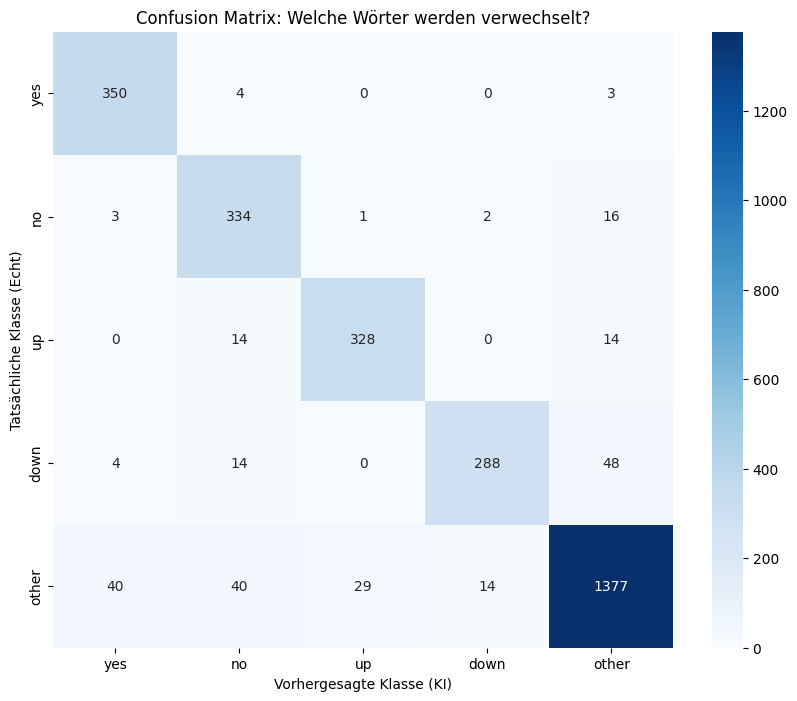

Konvertiere Modell in ONNX...


ERFOLG: Modell wurde unter Models/TensorFlow.onnx gespeichert.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tf2onnx
import tensorflow as tf

print("Starte finale Evaluation auf den Testdaten...")
test_results = model.evaluate(test_ds, return_dict=True)
print(f"\nFINALE TEST-GENAUIGKEIT: {test_results['accuracy'] * 100:.2f}%")

# 2. Confusion Matrix (Detaillierte Fehleranalyse)
y_pred = []
y_true = []

print("Generiere Vorhersagen für die Confusion Matrix...")
for audio, label in test_ds:
    preds = model.predict(audio, verbose=0)
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
    y_true.extend(label.numpy())

# Matrix berechnen
cm = confusion_matrix(y_true, y_pred)

# Plotten der Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Vorhergesagte Klasse (KI)')
plt.ylabel('Tatsächliche Klasse (Echt)')
plt.title('Confusion Matrix: Welche Wörter werden verwechselt?')
plt.show()

print("Konvertiere Modell in ONNX...")

input_signature = [
    tf.TensorSpec(
        [None, 40, 81, 1],
        tf.float32,
        name="mfcc_input"
    )
]

onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    opset=18
)

onnx_save_path = "Models/TensorFlow.onnx"

with open(onnx_save_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"ERFOLG: Modell wurde unter {onnx_save_path} gespeichert.")

## 8. Einzelauswertung der Testdateien

In [10]:
for i, file_path in enumerate(test_paths):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Padding/Cutting auf NUM_SAMPLES
    audio_length = tf.shape(audio)[0]
    padding = tf.maximum(NUM_SAMPLES - audio_length, 0)
    audio = tf.pad(audio, [[0, padding]])
    audio = audio[:NUM_SAMPLES]

    # Native MFCC extrahieren
    mfcc = extract_mfcc(audio)
    input_tensor = tf.expand_dims(mfcc, axis=0)
    prediction_logits = model.predict(input_tensor, verbose=0)

    probabilities = tf.nn.softmax(prediction_logits[0])
    predicted_idx = tf.argmax(probabilities).numpy()
    confidence = probabilities[predicted_idx].numpy()

    true_idx = test_labels[i]
    true_label = CLASSES[true_idx]

    file_name = os.path.basename(file_path)

    print(f"{file_name:<40} | {true_label:<15} | {CLASSES[predicted_idx]:<15} | {confidence*100:>6.2f}%")

    if i >= 250:
        print("...")
        break

173ce2be_nohash_0.wav                    | other           | other           |  74.45%
adec6a94_nohash_1.wav                    | no              | no              |  99.58%


0b40aa8e_nohash_1.wav                    | other           | other           |  99.52%
aba19127_nohash_0.wav                    | other           | other           |  99.89%


25132942_nohash_0.wav                    | other           | other           |  53.85%
c1b7c224_nohash_0.wav                    | other           | other           |  99.98%


b843de62_nohash_2.wav                    | no              | no              |  99.81%


c0445658_nohash_0.wav                    | other           | no              |  27.88%


...

cc6bae0d_nohash_0.wav                    | down            | down            |  43.77%
c44d2a58_nohash_1.wav                    | other           | other           |  99.98%
5af0ca83_nohash_2.wav                    | other           | other           |  99.70%


c7124b73_nohash_0.wav                    | other           | other           | 100.00%
f192e6b4_nohash_0.wav                    | down            | down            |  98.64%
1851e33b_nohash_1.wav                    | other           | other           | 100.00%


b0c0197e_nohash_1.wav                    | other           | other           |  83.33%
72be9202_nohash_0.wav                    | other           | other           |  98.85%
4b25f620_nohash_0.wav                    | other           | other           |  54.05%


5d9bb361_nohash_0.wav                    | other           | other           |  99.99%
5a0bc987_nohash_0.wav                    | other           | other           |  66.15%
ffb86d3c_nohash_3.wav                    | other           | other           |  92.50%


7c1d8533_nohash_1.wav                    | other           | other           | 100.00%
...
